<a href="https://colab.research.google.com/github/Ashishjoshi794/computer-vision/blob/main/image_Processing_using_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
image = cv2.imread("img.jpg")

In [ ]:
from google.colab import files

uploaded = files.upload()

image_name = list(uploaded.keys())[0]

print("Uploaded image:", image_name)

Saving Screenshot 2026-09-17 134608.png to Screenshot 2026-09-17 134608.png
Uploaded image: Screenshot 2026-09-17 134608.png



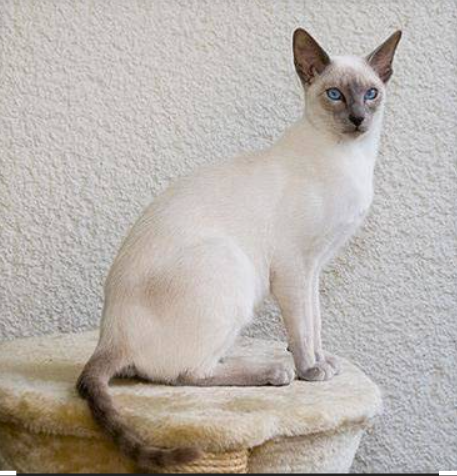

Crop coordinates received from UI. Please re-run this cell to apply crop.
Crop coordinates received from UI. Please re-run this cell to apply crop.


In [ ]:
# Read image
image = cv2.imread(image_name)

# Convert image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to base64 so it can be displayed in the browser
pil_image = Image.fromarray(image_rgb)

buffer = io.BytesIO()
pil_image.save(buffer, format="PNG")

image_base64 = base64.b64encode(buffer.getvalue()).decode()

# Show interactive cropping tool
display(HTML(f"""
<style>
#crop-container {{
    position: relative;
    display: inline-block;
}}

#crop-image {{
    display: block;
    max-width: 800px;
    cursor: crosshair;
}}

#selection {{
    position: absolute;
    border: 3px solid red;
    display: none;
    pointer-events: none;
}}

button {{
    margin-top: 15px;
    padding: 10px 20px;
    font-size: 16px;
    cursor: pointer;
}}
</style>

<div id="crop-container">
    <img id="crop-image"
         src="data:image/png;base64,{image_base64}">
    <div id="selection"></div>
</div>

<br>

<button onclick="cropImage()">Crop & Save</button>

<p id="result"></p>

<script>
let img = document.getElementById("crop-image");
let selection = document.getElementById("selection");

let startX = 0;
let startY = 0;
let endX = 0;
let endY = 0;
let selecting = false;

img.addEventListener("mousedown", function(event) {{

    let rect = img.getBoundingClientRect();

    startX = event.clientX - rect.left;
    startY = event.clientY - rect.top;

    selecting = true;

    selection.style.left = startX + "px";
    selection.style.top = startY + "px";
    selection.style.width = "0px";
    selection.style.height = "0px";
    selection.style.display = "block";
}});

img.addEventListener("mousemove", function(event) {{

    if (!selecting) return;

    let rect = img.getBoundingClientRect();

    endX = event.clientX - rect.left;
    endY = event.clientY - rect.top;

    let x = Math.min(startX, endX);
    let y = Math.min(startY, endY);

    let width = Math.abs(endX - startX);
    let height = Math.abs(endY - startY);

    selection.style.left = x + "px";
    selection.style.top = y + "px";
    selection.style.width = width + "px";
    selection.style.height = height + "px";
}});

img.addEventListener("mouseup", function(event) {{

    selecting = false;

    let rect = img.getBoundingClientRect();

    endX = event.clientX - rect.left;
    endY = event.clientY - rect.top;
}});

async function cropImage() {{

    let rect = img.getBoundingClientRect();

    let x = Math.min(startX, endX);
    let y = Math.min(startY, endY);

    let width = Math.abs(endX - startX);
    let height = Math.abs(endY - startY);

    if (width < 10 || height < 10) {{
        document.getElementById("result").innerText =
            "Please select a crop area first.";
        return;
    }}

    // Get original image size
    let originalWidth = img.naturalWidth;
    let originalHeight = img.naturalHeight;

    // Convert displayed coordinates to original coordinates
    let scaleX = originalWidth / rect.width;
    let scaleY = originalHeight / rect.height;

    let originalX = Math.round(x * scaleX);
    let originalY = Math.round(y * scaleY);

    let originalWidthCrop = Math.round(width * scaleX);
    let originalHeightCrop = Math.round(height * scaleY);

    let result = {{
        x: originalX,
        y: originalY,
        width: originalWidthCrop,
        height: originalHeightCrop
    }};

    document.getElementById("result").innerText =
        "Crop area selected successfully!";

    google.colab.kernel.invokeFunction(
        "notebook.getCropCoordinates",
        [result],
        {{}}
    );
}}
</script>
"""))

In [ ]:
crop_coordinates = None

def get_crop_coordinates(data):
    global crop_coordinates
    crop_coordinates = data
    print("Crop coordinates:", data)

output.register_callback(
    "notebook.getCropCoordinates",
    get_crop_coordinates
)

NameError: name 'output' is not defined